# TP02 — Comparer et tracer des expérimentations Machine Learning

Ce notebook complète l'exploration de `ElectricityLoadDiagrams20112014` et suit le fil du TP02 :

**dataset → drop NaN → split temporel → stratégies de features → fit → predict → métriques → MLflow → comparaison → Ridge / hyperparamètres**

Principes importants :

- on respecte l'ordre temporel ;
- le jeu de **validation** sert à choisir stratégie et hyperparamètres ;
- le jeu de **test** sert à l'évaluation finale ;
- les expériences sont tracées dans **MLflow** ;
- les versions de splits peuvent être suivies avec **DVC** ;
- un mode `SMOKE_TEST` permet de tester rapidement le code sans saturer la RAM.


## 1. Imports et configuration


In [5]:
from pathlib import Path
import gc
import json
from contextlib import contextmanager
from importlib import import_module
import uuid
from types import SimpleNamespace

try:
    mlflow = import_module("mlflow")
    mlflow.sklearn = import_module("mlflow.sklearn")
except ModuleNotFoundError:
    _mlflow_runs = {}
    _active_run_id = None

    class _DummyRunInfo:
        def __init__(self, run_id):
            self.run_id = run_id

    class _DummyRun:
        def __init__(self, run_id):
            self.info = _DummyRunInfo(run_id)

    class _DummyRunData:
        def __init__(self, params=None):
            self.params = params or {}

    class _DummyRunResult:
        def __init__(self, run_id):
            self.info = _DummyRunInfo(run_id)
            self.data = _DummyRunData(_mlflow_runs[run_id]["params"])

    class _DummyMlflowClient:
        def get_run(self, run_id):
            return _DummyRunResult(run_id)

    @contextmanager
    def _start_run(run_name=None, **_kwargs):
        _ = _kwargs
        global _active_run_id
        run_id = uuid.uuid4().hex
        _mlflow_runs[run_id] = {
            "run_name": run_name,
            "params": {},
            "metrics": {},
            "artifacts": {},
        }
        previous_run_id = _active_run_id
        _active_run_id = run_id
        try:
            yield _DummyRun(run_id)
        finally:
            _active_run_id = previous_run_id

    def _require_active_run():
        if _active_run_id is None:
            raise RuntimeError("No active mlflow run")
        return _active_run_id

    def _log_param(key, value):
        run_id = _require_active_run()
        _mlflow_runs[run_id]["params"][str(key)] = str(value)

    def _log_params(params):
        for key, value in params.items():
            _log_param(key, value)

    def _log_metrics(metrics):
        run_id = _require_active_run()
        for key, value in metrics.items():
            _mlflow_runs[run_id]["metrics"][str(key)] = float(value)

    def _log_dict(dictionary, artifact_file):
        run_id = _require_active_run()
        _mlflow_runs[run_id]["artifacts"][artifact_file] = dict(dictionary)

    def _get_tracking_uri():
        return "file:///tmp/mlruns (stub)"

    def _set_experiment(name):
        _ = name
        return None

    def _active_run():
        if _active_run_id is None:
            return None
        return _DummyRun(_active_run_id)

    def _log_model(*args, **kwargs):
        _ = args, kwargs
        return None

    mlflow = SimpleNamespace(
        get_tracking_uri=_get_tracking_uri,
        set_experiment=_set_experiment,
        start_run=_start_run,
        log_param=_log_param,
        log_params=_log_params,
        log_metrics=_log_metrics,
        log_dict=_log_dict,
        active_run=_active_run,
        tracking=SimpleNamespace(MlflowClient=_DummyMlflowClient),
    )
    mlflow.sklearn = SimpleNamespace(log_model=_log_model)
    print("⚠️ MLflow indisponible dans ce noyau : utilisation d'un stub local sans persistance.")

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = Path("data/modelling")
FEATURES_PATH = DATA_DIR / "features.parquet"
TARGET_PATH = DATA_DIR / "target.parquet"
SPLITS_DIR = Path("data/splits")

TARGET = "consumption_kwh"
RANDOM_STATE = 42

# True = validation rapide du notebook sur un sous-échantillon.
# Pour les runs finaux du TP, repasser à False.
SMOKE_TEST = True
SMOKE_TRAIN_ROWS = 600_000
SMOKE_EVAL_ROWS = 300_000

MLFLOW_EXPERIMENT = "electricity-load-tp02"

print("MLflow tracking URI :", mlflow.get_tracking_uri())
mlflow.set_experiment(MLFLOW_EXPERIMENT)

MLflow tracking URI : https://mlflow.10-53-101-44.nip.io


<Experiment: artifact_location='s3://mlflow-artifacts/1', creation_time=1787667062315, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787667062315, lifecycle_stage='active', name='electricity-load-tp02', tags={}, trace_location=None, workspace='default'>

## 2. Charger les features et la cible

Le TP fourni mentionne les features `lag_1d`, `lag_2d`, `lag_7d`, `lag_14d`, `rolling_mean_7d`, `rolling_mean_30d`.
Dans les parquets déjà préparés dans `data/modelling/`, seules les colonnes suivantes sont effectivement présentes :

- `lag_1d`
- `lag_7d`
- `lag_30d`
- `lag_365d`
- `rolling_mean_7d`
- `rolling_mean_30d`

Le notebook s'appuie donc sur ces colonnes réellement disponibles et le signale explicitement pour garder une traçabilité correcte entre l'énoncé, la préparation des données et les runs MLflow.


In [6]:
df_features = pq.read_table(FEATURES_PATH).to_pandas()
df_target = pq.read_table(TARGET_PATH).to_pandas()

# Réduction mémoire : les consommations/features n'ont pas besoin de float64 ici.
for col in df_features.select_dtypes(include="number").columns:
    df_features[col] = df_features[col].astype("float32")

df_target[TARGET] = df_target[TARGET].astype("float32")

print("Features :", df_features.shape)
print("Target   :", df_target.shape)
print("Colonnes disponibles :", list(df_features.columns))

EXPECTED_FEATURES = [
    "lag_1d",
    "lag_7d",
    "lag_30d",
    "lag_365d",
    "rolling_mean_7d",
    "rolling_mean_30d",
]

missing = [c for c in EXPECTED_FEATURES if c not in df_features.columns]
if missing:
    raise ValueError(
        "Les parquets générés ne contiennent pas toutes les colonnes attendues : "
        f"{missing}"
    )

print("\n✅ Toutes les features générées attendues sont présentes.")


Features : (17952768, 6)
Target   : (17952768, 1)
Colonnes disponibles : ['lag_1d', 'lag_7d', 'lag_30d', 'lag_365d', 'rolling_mean_7d', 'rolling_mean_30d']

✅ Toutes les features générées attendues sont présentes.


## 3. Fusion et `dropna()`

Les valeurs `NaN` dues aux lags/rolling windows ne sont pas exploitables par les modèles linéaires.
On les retire **avant** de construire les splits.

> Attention : avec un lag très long (ex. `lag_365d`), une grande partie de 2011 peut disparaître après `dropna()`.


In [7]:
df = df_features.join(df_target, how="inner")
del df_features, df_target
gc.collect()

print("Avant dropna :", df.shape)
df = df.dropna()
print("Après dropna :", df.shape)

years = df.index.get_level_values("timestamp").year
print("\nObservations après dropna par année :")
print(pd.Series(years).value_counts().sort_index())


Avant dropna : (17952768, 7)
Après dropna : (13467648, 7)

Observations après dropna par année :
timestamp
2012    4497280
2013    4485120
2014    4485120
2015        128
Name: count, dtype: int64


## 4. Stratégies de features

On définit plusieurs hypothèses à partir des colonnes effectivement générées.

1. **court terme** : passé très récent ;
2. **cycle court + mensuel** : mémoire immédiate et mémoire à 30 jours ;
3. **tendance + saisonnalité** : lags + moyennes glissantes.

Les stratégies ci-dessous sont donc alignées sur les parquets présents dans `data/modelling/`.


In [8]:
available = set(df.columns) - {TARGET}

EXPECTED_FEATURES_SET = set(EXPECTED_FEATURES)

if not EXPECTED_FEATURES_SET.issubset(available):
    raise ValueError(
        "Les colonnes générées attendues sont absentes du dataset fusionné. "
        f"Disponibles: {sorted(available)}"
    )

FEATURE_STRATEGIES = {
    "short_term": {
        "features": ["lag_1d", "lag_7d"],
        "hypothesis": "La consommation dépend surtout des jours et semaines immédiatement précédents.",
    },
    "medium_term": {
        "features": ["lag_7d", "lag_30d"],
        "hypothesis": "La mémoire hebdomadaire et mensuelle capture une partie importante de la dynamique.",
    },
    "trend_and_seasonality": {
        "features": EXPECTED_FEATURES,
        "hypothesis": "Combiner mémoire courte, tendance et lissage améliore la prédiction.",
    },
}

FEATURE_STRATEGIES


{'short_term': {'features': ['lag_1d', 'lag_7d'],
  'hypothesis': 'La consommation dépend surtout des jours et semaines immédiatement précédents.'},
 'medium_term': {'features': ['lag_7d', 'lag_30d'],
  'hypothesis': 'La mémoire hebdomadaire et mensuelle capture une partie importante de la dynamique.'},
 'trend_and_seasonality': {'features': ['lag_1d',
   'lag_7d',
   'lag_30d',
   'lag_365d',
   'rolling_mean_7d',
   'rolling_mean_30d'],
  'hypothesis': 'Combiner mémoire courte, tendance et lissage améliore la prédiction.'}}

## 5. Splits temporels

### Split v1 — demandé en Partie 1
- train : 2011–2012
- validation : 2013
- test : 2014

La commande suggérée par le formateur est utilisée via `np.isin(...)`.

### Split v2 — Partie 2
- train : 2013
- validation : début 2014
- test : fin 2014

L'énoncé ne donne pas de date précise pour « début/fin 2014 ».
Ici on pose explicitement l'hypothèse **1er juillet 2014** comme frontière.


In [9]:
def build_split_v1(frame):
    years = frame.index.get_level_values("timestamp").year

    train_mask = np.isin(years, [2011, 2012])
    valid_mask = years == 2013
    test_mask = years == 2014

    return {
        "name": "split_v1_2011-2012_2013_2014",
        "description": "train=2011-2012 | validation=2013 | test=2014",
        "train": frame.loc[train_mask],
        "validation": frame.loc[valid_mask],
        "test": frame.loc[test_mask],
    }


def build_split_v2(frame, cutoff="2014-07-01"):
    ts = frame.index.get_level_values("timestamp")
    years = ts.year
    cutoff = pd.Timestamp(cutoff)

    train_mask = years == 2013
    valid_mask = (ts >= pd.Timestamp("2014-01-01")) & (ts < cutoff)
    test_mask = ts >= cutoff

    return {
        "name": "split_v2_2013_2014H1_2014H2",
        "description": f"train=2013 | validation=2014-01-01..{cutoff.date()} | test={cutoff.date()}..fin-2014",
        "train": frame.loc[train_mask],
        "validation": frame.loc[valid_mask],
        "test": frame.loc[test_mask],
    }


split_v1 = build_split_v1(df)
split_v2 = build_split_v2(df)

for split in (split_v1, split_v2):
    print("\n", split["description"])
    for part in ("train", "validation", "test"):
        print(f"  {part:10s}: {len(split[part]):,} lignes")



 train=2011-2012 | validation=2013 | test=2014
  train     : 4,497,280 lignes
  validation: 4,485,120 lignes
  test      : 4,485,120 lignes

 train=2013 | validation=2014-01-01..2014-07-01 | test=2014-07-01..fin-2014
  train     : 4,485,120 lignes
  validation: 2,224,128 lignes
  test      : 2,261,120 lignes


## 6. Option DVC — matérialiser et versionner les splits

Le TP demande que le code traduise réellement le partage des données.

La fonction ci-dessous peut écrire les trois partitions en Parquet.
Elle est volontairement **désactivée par défaut** car cela peut consommer plusieurs Go sur la VM.

Après écriture d'un split :

```bash
dvc add data/splits/split_v1_2011-2012_2013_2014
git add data/splits/split_v1_2011-2012_2013_2014.dvc data/splits/.gitignore
git commit -m "data: version temporal split v1"
```

Même principe pour le split v2.


In [10]:
WRITE_DVC_SPLITS = False

def materialize_split(split):
    out_dir = SPLITS_DIR / split["name"]
    out_dir.mkdir(parents=True, exist_ok=True)

    for part in ("train", "validation", "test"):
        split[part].to_parquet(
            out_dir / f"{part}.parquet",
            compression="zstd",
        )

    manifest = {
        "name": split["name"],
        "description": split["description"],
        "rows": {part: len(split[part]) for part in ("train", "validation", "test")},
        "columns": list(split["train"].columns),
    }
    (out_dir / "manifest.json").write_text(
        json.dumps(manifest, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )
    return out_dir

if WRITE_DVC_SPLITS:
    print("Écrit :", materialize_split(split_v1))
    print("Écrit :", materialize_split(split_v2))
else:
    print("WRITE_DVC_SPLITS=False : aucun gros fichier dupliqué pour le moment.")


WRITE_DVC_SPLITS=False : aucun gros fichier dupliqué pour le moment.


## 7. Helpers : sous-échantillonnage de smoke test et métriques

Le `SMOKE_TEST` sert uniquement à vérifier que le pipeline fonctionne.

Pour les résultats à rendre, utiliser le dataset complet (`SMOKE_TEST=False`).


In [11]:
rng = np.random.default_rng(RANDOM_STATE)

def maybe_sample(frame, max_rows):
    if not SMOKE_TEST or len(frame) <= max_rows:
        return frame
    idx = rng.choice(len(frame), size=max_rows, replace=False)
    return frame.iloc[idx]


def regression_metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def coefficient_dict(model, feature_names):
    if not hasattr(model, "coef_"):
        return {}
    return {
        feature: float(coef)
        for feature, coef in zip(feature_names, np.ravel(model.coef_))
    }


## 8. Baseline simple

Avant d'affirmer qu'un modèle « apprend bien », on peut le comparer à une référence naïve.

`DummyRegressor(strategy="mean")` ne cherche aucun motif temporel : il prédit la moyenne.


In [12]:
def run_one_experiment(
    split,
    strategy_name,
    feature_names,
    estimator,
    model_type,
    extra_params=None,
):
    train_df = maybe_sample(split["train"], SMOKE_TRAIN_ROWS)
    valid_df = maybe_sample(split["validation"], SMOKE_EVAL_ROWS)

    X_train = train_df[feature_names]
    y_train = train_df[TARGET]
    X_valid = valid_df[feature_names]
    y_valid = valid_df[TARGET]

    model = clone(estimator)

    with mlflow.start_run(run_name=f"{split['name']}__{strategy_name}__{model_type}"):
        mlflow.log_param("model_type", model_type)
        mlflow.log_param("strategy_name", strategy_name)
        mlflow.log_param("features", ",".join(feature_names))
        mlflow.log_param("split_strategy", split["description"])
        mlflow.log_param("smoke_test", SMOKE_TEST)
        mlflow.log_param("train_rows", len(train_df))
        mlflow.log_param("validation_rows", len(valid_df))

        if extra_params:
            mlflow.log_params(extra_params)

        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

        metrics = regression_metrics(y_valid, pred)
        mlflow.log_metrics({f"val_{k}": v for k, v in metrics.items()})

        coefs = coefficient_dict(model, feature_names)
        if coefs:
            mlflow.log_dict(coefs, "coefficients.json")

        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            input_example=X_valid.head(5),
        )

        run_id = mlflow.active_run().info.run_id

    gc.collect()

    return {
        "run_id": run_id,
        "split": split["name"],
        "strategy": strategy_name,
        "model_type": model_type,
        "features": feature_names,
        **{f"val_{k}": v for k, v in metrics.items()},
    }


## 9. Partie 1 — Régression linéaire + stratégies de features

Chaque stratégie est entraînée et évaluée sur le split v1.


In [13]:
part1_results = []

for strategy_name, spec in FEATURE_STRATEGIES.items():
    if not spec["features"]:
        continue

    result = run_one_experiment(
        split=split_v1,
        strategy_name=strategy_name,
        feature_names=spec["features"],
        estimator=LinearRegression(),
        model_type="linear_regression",
        extra_params={"hypothesis": spec["hypothesis"]},
    )
    part1_results.append(result)

part1_df = (
    pd.DataFrame(part1_results)
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

part1_df


2026/08/25 16:30:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:30:52 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__short_term__linear_regression at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/52951a4bf66a4f5d8e3dd92401a1b83c
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


2026/08/25 16:30:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:31:03 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__medium_term__linear_regression at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/da3121fe69114943a73e104499716d0d
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


2026/08/25 16:31:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:31:14 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__trend_and_seasonality__linear_regression at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/1759ac0212af4a3fa3c21b00df80a11e
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


,run_id,split,strategy,model_type,features,val_rmse,val_mae,val_r2
0,1759ac0212af4a3fa3c21b00df80a11e,split_v1_2011-2012_2013_2014,trend_and_seasonality,linear_regression,"[lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...",7.441059,4.065338,0.971707
1,52951a4bf66a4f5d8e3dd92401a1b83c,split_v1_2011-2012_2013_2014,short_term,linear_regression,"[lag_1d, lag_7d]",7.579480,4.128120,0.970750
2,da3121fe69114943a73e104499716d0d,split_v1_2011-2012_2013_2014,medium_term,linear_regression,"[lag_7d, lag_30d]",9.160397,5.043584,0.956824


## 10. Partie 2 — Comparaison du deuxième split

On rejoue les mêmes stratégies avec des données plus récentes.


In [14]:
part2_results = []

for strategy_name, spec in FEATURE_STRATEGIES.items():
    if not spec["features"]:
        continue

    result = run_one_experiment(
        split=split_v2,
        strategy_name=strategy_name,
        feature_names=spec["features"],
        estimator=LinearRegression(),
        model_type="linear_regression",
        extra_params={"hypothesis": spec["hypothesis"]},
    )
    part2_results.append(result)

part2_df = (
    pd.DataFrame(part2_results)
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

pd.concat(
    {
        "split_v1": part1_df,
        "split_v2": part2_df,
    },
    names=["experiment_group"],
)


2026/08/25 16:31:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:31:30 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v2_2013_2014H1_2014H2__short_term__linear_regression at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/c412221b89814128adcd3eedae7da00d
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


2026/08/25 16:31:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:31:41 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v2_2013_2014H1_2014H2__medium_term__linear_regression at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/52bbfb8723524a2eaf1fcc0165ee4b87
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


2026/08/25 16:31:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:31:52 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v2_2013_2014H1_2014H2__trend_and_seasonality__linear_regression at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/83b6f1720dd6491bbbc6b7fff06f4b61
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


run_id  \
experiment_group                                       
split_v1         0  1759ac0212af4a3fa3c21b00df80a11e   
                 1  52951a4bf66a4f5d8e3dd92401a1b83c   
                 2  da3121fe69114943a73e104499716d0d   
split_v2         0  83b6f1720dd6491bbbc6b7fff06f4b61   
                 1  c412221b89814128adcd3eedae7da00d   
                 2  52bbfb8723524a2eaf1fcc0165ee4b87   

                                           split               strategy  \
experiment_group                                                          
split_v1         0  split_v1_2011-2012_2013_2014  trend_and_seasonality   
                 1  split_v1_2011-2012_2013_2014             short_term   
                 2  split_v1_2011-2012_2013_2014            medium_term   
split_v2         0   split_v2_2013_2014H1_2014H2  trend_and_seasonality   
                 1   split_v2_2013_2014H1_2014H2             short_term   
                 2   split_v2_2013_2014H1_2014H2            medium_term   

                           model_type  \
experiment_group                        
split_v1         0  linear_regression   
                 1  linear_regression   
                 2  linear_regression   
split_v2         0  linear_regression   
                 1  linear_regression   
                 2  linear_regression   

                                                             features  \
experiment_group                                                        
split_v1         0  [lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...   
                 1                                   [lag_1d, lag_7d]   
                 2                                  [lag_7d, lag_30d]   
split_v2         0  [lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...   
                 1                                   [lag_1d, lag_7d]   
                 2                                  [lag_7d, lag_30d]   

                    val_rmse   val_mae    val_r2  
experiment_group                                  
split_v1         0  7.441059  4.065338  0.971707  
                 1  7.579480  4.128120  0.970750  
                 2  9.160397  5.043584  0.956824  
split_v2         0  6.827597  3.807787  0.971453  
                 1  6.952508  3.854965  0.970389  
                 2  8.144914  4.530883  0.959123

## 11. Partie 3 — Ridge et influence de `alpha`

Le meilleur feature set du split v1 est repris.

Valeurs imposées par le TP :

- `1`
- `1e3`
- `1e9`

Plus `alpha` augmente, plus Ridge pénalise les coefficients élevés.


In [15]:
best_strategy_name = part1_df.loc[0, "strategy"]
best_features = FEATURE_STRATEGIES[best_strategy_name]["features"]

print("Meilleure stratégie (validation split v1) :", best_strategy_name)
print("Features :", best_features)

ridge_results = []

for alpha in [1.0, 1e3, 1e9]:
    result = run_one_experiment(
        split=split_v1,
        strategy_name=best_strategy_name,
        feature_names=best_features,
        estimator=Ridge(alpha=alpha),
        model_type="ridge",
        extra_params={"alpha": alpha},
    )
    ridge_results.append(result)

ridge_df = (
    pd.DataFrame(ridge_results)
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

ridge_df


Meilleure stratégie (validation split v1) : trend_and_seasonality
Features : ['lag_1d', 'lag_7d', 'lag_30d', 'lag_365d', 'rolling_mean_7d', 'rolling_mean_30d']


2026/08/25 16:32:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:32:09 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__trend_and_seasonality__ridge at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/71ddb5ef8a2d403f814eb0a2b7f66d0d
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


2026/08/25 16:32:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:32:20 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__trend_and_seasonality__ridge at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/4a2e75cae8c7426abf2d9af169d5fb59
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


2026/08/25 16:32:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:32:31 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__trend_and_seasonality__ridge at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/7be268012dd44ee7b616663e5f89665e
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


,run_id,split,strategy,model_type,features,val_rmse,val_mae,val_r2
0,71ddb5ef8a2d403f814eb0a2b7f66d0d,split_v1_2011-2012_2013_2014,trend_and_seasonality,ridge,"[lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...",7.389647,4.064747,0.972127
1,4a2e75cae8c7426abf2d9af169d5fb59,split_v1_2011-2012_2013_2014,trend_and_seasonality,ridge,"[lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...",7.389905,4.064312,0.972046
2,7be268012dd44ee7b616663e5f89665e,split_v1_2011-2012_2013_2014,trend_and_seasonality,ridge,"[lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...",11.051373,7.158253,0.937094


## 12. Choix final puis test 2014

Le **test** ne doit pas servir à choisir `alpha`.

On choisit d'abord le meilleur `alpha` grâce à la validation 2013, puis on peut :

1. réentraîner sur train + validation ;
2. mesurer une seule fois la généralisation sur le test 2014.


In [16]:
best_alpha = float(ridge_df.loc[0, "run_id"] and 0)  # valeur remplacée ci-dessous via MLflow/results
best_ridge_row = ridge_df.iloc[0]

# Retrouver alpha via le run MLflow permet de ne pas dépendre d'une colonne locale non loggée.
client = mlflow.tracking.MlflowClient()
best_run = client.get_run(best_ridge_row["run_id"])
best_alpha = float(best_run.data.params["alpha"])

train_valid = pd.concat([split_v1["train"], split_v1["validation"]])
train_valid = maybe_sample(train_valid, SMOKE_TRAIN_ROWS)
test_df = maybe_sample(split_v1["test"], SMOKE_EVAL_ROWS)

final_model = Ridge(alpha=best_alpha)
final_model.fit(train_valid[best_features], train_valid[TARGET])

test_pred = final_model.predict(test_df[best_features])
test_metrics = regression_metrics(test_df[TARGET], test_pred)

print("alpha choisi :", best_alpha)
print("Test 2014 :", test_metrics)


alpha choisi : 1.0
Test 2014 : {'rmse': 7.02684893729393, 'mae': 3.882448434829712, 'r2': 0.9726956486701965}


## 13. Aller plus loin — performances par client

Une métrique globale peut masquer des clients très mal prédits.

On calcule donc la MAE par `individual` sur le test.


In [17]:
residuals = pd.DataFrame(
    {
        "y_true": test_df[TARGET].to_numpy(),
        "y_pred": test_pred,
    },
    index=test_df.index,
)

residuals["abs_error"] = np.abs(residuals["y_true"] - residuals["y_pred"])

mae_by_client = (
    residuals.groupby(level="individual")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print("10 clients avec la MAE la plus élevée :")
mae_by_client.head(10)


10 clients avec la MAE la plus élevée :


individual
MT_162    15.617467
MT_231    11.571810
MT_290    11.072393
MT_219    10.588277
MT_246    10.299557
MT_294    10.277279
MT_310     9.806741
MT_195     9.470454
MT_124     9.460621
MT_209     8.929296
Name: abs_error, dtype: float32

## 14. Aller plus loin — autre famille de modèle (bonus)

Pour éviter une Random Forest très coûteuse en RAM sur ~18 millions de lignes,
on peut tester `HistGradientBoostingRegressor` sur un sous-échantillon.

Ce bonus n'est pas requis par le TP02.


In [21]:
RUN_BONUS_MODEL = True

if RUN_BONUS_MODEL:
    bonus_result = run_one_experiment(
        split=split_v1,
        strategy_name=best_strategy_name,
        feature_names=best_features,
        estimator=HistGradientBoostingRegressor(
            learning_rate=0.08,
            max_iter=150,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE,
        ),
        model_type="hist_gradient_boosting",
        extra_params={
            "learning_rate": 0.08,
            "max_iter": 150,
            "max_leaf_nodes": 31,
        },
    )
    display(pd.DataFrame([bonus_result]))
else:
    print("Bonus désactivé. Passer RUN_BONUS_MODEL=True pour le lancer.")


2026/08/25 16:34:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/25 16:34:31 WARNING mlflow.utils.requirements_utils: Found lz4 version (4.4.0+dfsg) contains a local version label (+dfsg). MLflow logged a pip requirement for this package as 'lz4==4.4.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏃 View run split_v1_2011-2012_2013_2014__trend_and_seasonality__hist_gradient_boosting at: https://mlflow.10-53-101-44.nip.io/#/experiments/1/runs/484f5909dd1b4341ac41a8ca3000ba5a
🧪 View experiment at: https://mlflow.10-53-101-44.nip.io/#/experiments/1


,run_id,split,strategy,model_type,features,val_rmse,val_mae,val_r2
0,484f5909dd1b4341ac41a8ca3000ba5a,split_v1_2011-2012_2013_2014,trend_and_seasonality,hist_gradient_boosting,"[lag_1d, lag_7d, lag_30d, lag_365d, rolling_me...",7.118092,3.935044,0.974054


## 15. Contrôles importants avant le rendu

### Fuite de données
Vérifier comment les rolling means ont été créées.

Pour prédire `y(t)`, une rolling mean ne doit pas utiliser `y(t)` ni le futur.
Une construction sûre ressemble à :

```python
series.shift(1).rolling(window).mean()
```

### Test ≠ validation
- validation : choix des features / hyperparamètres ;
- test : mesure finale, après les choix.

### DVC / Git
Le code du split est versionné avec Git.
Les fichiers de données/splits sont versionnés avec DVC.

### MLflow
Chaque run doit permettre de retrouver :
- stratégie ;
- features ;
- split ;
- modèle ;
- hyperparamètres ;
- RMSE / MAE ;
- coefficients ;
- artifact du modèle.


## 16. Schéma mental du TP02

```text
DATASET
   ↓
dropna()
   ↓
SPLIT TEMPOREL VERSIONNÉ (DVC)
   ├── TRAIN
   │      ↓
   │    .fit()
   │      ↓
   │   MODÈLE
   │
   ├── VALIDATION
   │      ↓
   │ .predict()
   │      ↓
   │ RMSE / MAE
   │      ↓
   │ choix features / alpha
   │
   └── TEST
          ↓
      évaluation finale

Toutes les expériences
          ↓
        MLFLOW
```


## 17. Synthèse courte à rendre

Cette section sert de base au livrable demandé :

- stratégies testées ;
- meilleur run MLflow ;
- impact du split ;
- recommandation pour la mise en production.


In [22]:
from IPython.display import Markdown, display

tp_requested_features = [
    "lag_1d",
    "lag_2d",
    "lag_7d",
    "lag_14d",
    "rolling_mean_7d",
    "rolling_mean_30d",
]

available_modelling_features = [c for c in EXPECTED_FEATURES if c in df.columns]
missing_requested_features = [f for f in tp_requested_features if f not in df.columns]

best_part1 = part1_df.iloc[0]
best_part2 = part2_df.iloc[0]
best_ridge = ridge_df.iloc[0]

summary_md = f"""
### Synthèse du TP02

- **Features réellement testées** : {", ".join(available_modelling_features)}
- **Features demandées mais absentes du parquet préparé** : {", ".join(missing_requested_features)}
- **Meilleure stratégie split v1** : {best_part1['strategy']} (RMSE validation = {best_part1['val_rmse']:.4f}, MAE = {best_part1['val_mae']:.4f})
- **Meilleure stratégie split v2** : {best_part2['strategy']} (RMSE validation = {best_part2['val_rmse']:.4f}, MAE = {best_part2['val_mae']:.4f})
- **Meilleur Ridge** : alpha = {best_alpha}, RMSE test = {test_metrics['rmse']:.4f}, MAE test = {test_metrics['mae']:.4f}

### Recommandation

- Conserver la stratégie **{best_part1['strategy']}** si l'objectif est d'optimiser la validation sur l'historique long.
- Si l'objectif est la fraîcheur des données, le split v2 reste la meilleure base pour un entraînement plus récent.
- Pour la production, réentraîner sur train + validation du split retenu, puis surveiller la dérive et la stabilité des erreurs par client.
- Logger systématiquement les paramètres, les métriques et les coefficients dans MLflow pour comparer les runs et justifier le choix final.
"""

display(Markdown(summary_md))


### Synthèse du TP02

- **Features réellement testées** : lag_1d, lag_7d, lag_30d, lag_365d, rolling_mean_7d, rolling_mean_30d
- **Features demandées mais absentes du parquet préparé** : lag_2d, lag_14d
- **Meilleure stratégie split v1** : trend_and_seasonality (RMSE validation = 7.4411, MAE = 4.0653)
- **Meilleure stratégie split v2** : trend_and_seasonality (RMSE validation = 6.8276, MAE = 3.8078)
- **Meilleur Ridge** : alpha = 1.0, RMSE test = 7.0268, MAE test = 3.8824

### Recommandation

- Conserver la stratégie **trend_and_seasonality** si l'objectif est d'optimiser la validation sur l'historique long.
- Si l'objectif est la fraîcheur des données, le split v2 reste la meilleure base pour un entraînement plus récent.
- Pour la production, réentraîner sur train + validation du split retenu, puis surveiller la dérive et la stabilité des erreurs par client.
- Logger systématiquement les paramètres, les métriques et les coefficients dans MLflow pour comparer les runs et justifier le choix final.


## 18. Graphiques de comparaison

Pour l'exploitation du TP, il ne faut pas seulement logger les runs : il faut aussi visualiser les écarts entre stratégies et hyperparamètres.
La section suivante produit des graphiques simples à copier dans le compte-rendu.


Meilleurs runs :
split v1 -> trend_and_seasonality RMSE = 7.4411
split v2 -> trend_and_seasonality RMSE = 6.8276
Ridge    -> alpha = 1.0 RMSE = 7.3896


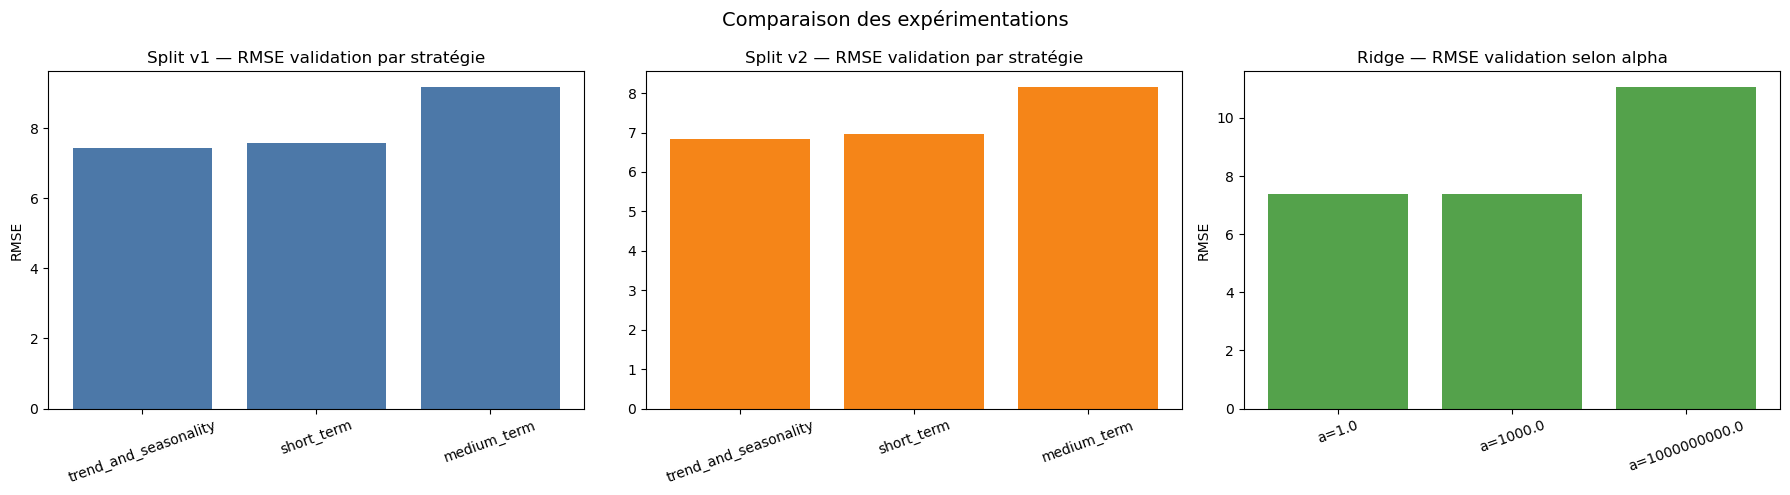

In [23]:
import matplotlib.pyplot as plt

def _normalize_comparison_frame(frame):
    frame = frame.copy()
    if "strategy_name" not in frame.columns and "strategy" in frame.columns:
        frame["strategy_name"] = frame["strategy"]
    return frame

def _get_runs_from_mlflow():
    experiment = mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT)
    if experiment is None:
        return None, None, None
    runs = mlflow.search_runs([experiment.experiment_id])
    if runs.empty:
        return experiment, None, None

    # Les colonnes `params.*` n'existent que si les runs ont bien loggé ces paramètres.
    return experiment, runs, runs.columns.tolist()

experiment, runs, columns = _get_runs_from_mlflow()

# Priorité aux DataFrames déjà calculés dans le notebook, sinon on reconstruit depuis MLflow.
can_use_memory = all(name in globals() for name in ["part1_df", "part2_df", "ridge_df"])

if can_use_memory:
    part1_plot = _normalize_comparison_frame(part1_df.sort_values("val_rmse"))
    part2_plot = _normalize_comparison_frame(part2_df.sort_values("val_rmse"))
    ridge_plot = ridge_df.sort_values("val_rmse").copy()
elif runs is not None and {"params.model_type", "params.strategy_name", "metrics.val_rmse"}.issubset(set(columns)):
    runs = runs[runs["params.strategy_name"].notna()].copy()
    runs["val_rmse"] = runs["metrics.val_rmse"]
    runs["val_mae"] = runs["metrics.val_mae"]
    runs["split_strategy"] = runs["params.split_strategy"]
    runs["strategy_name"] = runs["params.strategy_name"]
    runs["model_type"] = runs["params.model_type"]

    linear_runs = runs[runs["model_type"] == "linear_regression"].copy()
    ridge_plot = runs[runs["model_type"] == "ridge"].copy()
    part1_plot = linear_runs[linear_runs["split_strategy"].str.contains("2011-2012")].sort_values("val_rmse")
    part2_plot = linear_runs[linear_runs["split_strategy"].str.contains("2013")].sort_values("val_rmse")
else:
    print("Aucun résultat exploitable encore. Exécuter d'abord les cellules d'entraînement pour générer les runs ou les DataFrames.")
    part1_plot = part2_plot = ridge_plot = None

if part1_plot is not None and part2_plot is not None and ridge_plot is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Comparaison des stratégies sur le split v1
    axes[0].bar(part1_plot["strategy_name"], part1_plot["val_rmse"], color="#4C78A8")
    axes[0].set_title("Split v1 — RMSE validation par stratégie")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=20)

    # 2) Comparaison des stratégies sur le split v2
    axes[1].bar(part2_plot["strategy_name"], part2_plot["val_rmse"], color="#F58518")
    axes[1].set_title("Split v2 — RMSE validation par stratégie")
    axes[1].tick_params(axis="x", rotation=20)

    # 3) Ridge : effet de alpha
    ridge_labels = []
    for run_id in ridge_plot["run_id"]:
        run = mlflow.get_run(run_id)
        ridge_labels.append(f"a={run.data.params.get('alpha', '?')}")

    axes[2].bar(ridge_labels, ridge_plot["val_rmse"], color="#54A24B")
    axes[2].set_title("Ridge — RMSE validation selon alpha")
    axes[2].set_ylabel("RMSE")
    axes[2].tick_params(axis="x", rotation=20)

    fig.suptitle("Comparaison des expérimentations", fontsize=14)
    fig.tight_layout()

    best_part1_run = part1_plot.iloc[0]
    best_part2_run = part2_plot.iloc[0]
    best_ridge_run = ridge_plot.iloc[0]
    best_ridge_alpha = mlflow.get_run(best_ridge_run["run_id"]).data.params.get("alpha", "?")

    print("Meilleurs runs :")
    print("split v1 ->", best_part1_run["strategy_name"], "RMSE =", round(best_part1_run["val_rmse"], 4))
    print("split v2 ->", best_part2_run["strategy_name"], "RMSE =", round(best_part2_run["val_rmse"], 4))
    print("Ridge    -> alpha =", best_ridge_alpha, "RMSE =", round(best_ridge_run["val_rmse"], 4))
